In [1]:
# ===============================
# 1. Imports + GPU Config
# ===============================

import numpy as np
import pandas as pd
import os
import zipfile
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from xgboost import XGBClassifier

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, LSTM, Conv1D, MaxPooling1D,
    Dropout, Concatenate, BatchNormalization,
    Bidirectional, MultiHeadAttention,
    LayerNormalization, GlobalAveragePooling1D
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# GPU memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2026-03-08 01:54:58.245637: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772934898.620197      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772934898.722068      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772934899.641231      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772934899.641275      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772934899.641278      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# ===============================
# 2. Load Dataset
# ===============================

df = pd.read_csv("/kaggle/input/datasets/birdy654/eeg-brainwave-dataset-feeling-emotions/emotions.csv")

print("Dataset Shape:", df.shape)

print(df.head())

print("Missing Values:", df.isnull().sum().sum())

Dataset Shape: (2132, 2549)
   # mean_0_a  mean_1_a  mean_2_a  mean_3_a  mean_4_a  mean_d_0_a  mean_d_1_a  \
0        4.62      30.3    -356.0      15.6      26.3       1.070       0.411   
1       28.80      33.1      32.0      25.8      22.8       6.550       1.680   
2        8.90      29.4    -416.0      16.7      23.7      79.900       3.360   
3       14.90      31.6    -143.0      19.8      24.3      -0.584      -0.284   
4       28.30      31.3      45.2      27.3      24.5      34.800      -5.790   

   mean_d_2_a  mean_d_3_a  mean_d_4_a  ...  fft_741_b  fft_742_b  fft_743_b  \
0      -15.70        2.06        3.15  ...       23.5       20.3       20.3   
1        2.88        3.83       -4.82  ...      -23.3      -21.8      -21.8   
2       90.20       89.90        2.03  ...      462.0     -233.0     -233.0   
3        8.82        2.30       -1.97  ...      299.0     -243.0     -243.0   
4        3.06       41.40        5.52  ...       12.0       38.1       38.1   

   fft_744

label
NEUTRAL     716
NEGATIVE    708
POSITIVE    708
Name: count, dtype: int64


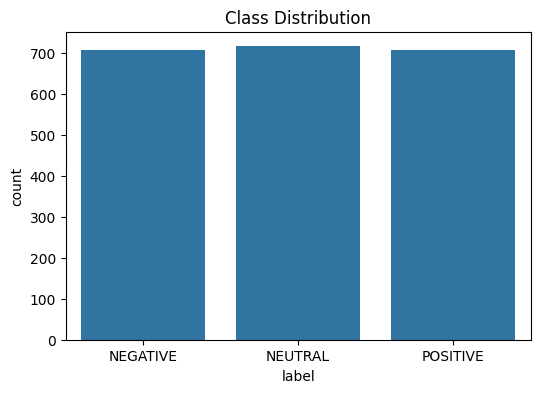

In [3]:
# ===============================
# 3. Class Distribution
# ===============================

print(df["label"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(x="label", data=df)

plt.title("Class Distribution")

plt.show()

In [4]:
# ===============================
# 4. Train-Test Split
# ===============================

X = df.drop("label", axis=1).values
y = df["label"].values


label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)


print("Label Mapping:")

for i,label in enumerate(label_encoder.classes_):
    print(label,"->",i)


X_train,X_test,y_train,y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)


print("Train Shape:",X_train.shape)
print("Test Shape:",X_test.shape)


# Save test samples
os.makedirs("test_npy_samples",exist_ok=True)

for i in range(len(X_test)):
    file_path = f"test_npy_samples/sample_{i}_label_{y_test[i]}.npy"
    np.save(file_path,X_test[i])


print("Saved .npy test samples")


# Create ZIP file
zip_path = "test_npy_samples.zip"

with zipfile.ZipFile(zip_path,'w') as zipf:
    for root,dirs,files in os.walk("test_npy_samples"):
        for file in files:
            zipf.write(os.path.join(root,file))


print("ZIP created:",zip_path)

Label Mapping:
NEGATIVE -> 0
NEUTRAL -> 1
POSITIVE -> 2
Train Shape: (1705, 2548)
Test Shape: (427, 2548)
Saved .npy test samples
ZIP created: test_npy_samples.zip


In [5]:
# ===============================
# 5. Scaling
# ===============================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# reshape for CNN

X_train = X_train.reshape(X_train.shape[0],X_train.shape[1],1)

X_test = X_test.reshape(X_test.shape[0],X_test.shape[1],1)


y_train_cat = to_categorical(y_train,3)

y_test_cat = to_categorical(y_test,3)

In [6]:
# ===============================
# 6. Deep Model
# ===============================

input_layer = Input(shape=(X_train.shape[1],1))


# Multi-scale CNN
cnn1 = Conv1D(128,3,activation='relu',padding='same')(input_layer)
cnn1 = BatchNormalization()(cnn1)
cnn1 = MaxPooling1D(2)(cnn1)


cnn2 = Conv1D(128,5,activation='relu',padding='same')(input_layer)
cnn2 = BatchNormalization()(cnn2)
cnn2 = MaxPooling1D(2)(cnn2)


cnn3 = Conv1D(128,7,activation='relu',padding='same')(input_layer)
cnn3 = BatchNormalization()(cnn3)
cnn3 = MaxPooling1D(2)(cnn3)


cnn4 = Conv1D(128,11,activation='relu',padding='same')(input_layer)
cnn4 = BatchNormalization()(cnn4)
cnn4 = MaxPooling1D(2)(cnn4)


merged = Concatenate()([cnn1,cnn2,cnn3,cnn4])


# Transformer attention
attn_output = MultiHeadAttention(num_heads=4,key_dim=64)(merged,merged)

attn_output = LayerNormalization()(attn_output + merged)


# BiLSTM
bilstm = Bidirectional(LSTM(256,return_sequences=True))(attn_output)


# pooling
gap = GlobalAveragePooling1D()(bilstm)


feature_vector = Dense(256,activation='relu')(gap)

drop = Dropout(0.4)(feature_vector)

output = Dense(3,activation='softmax')(drop)


deep_model = Model(inputs=input_layer,outputs=output)


deep_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


deep_model.summary()

I0000 00:00:1772935006.635581      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772935006.641545      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2548, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2548, 128) │        512 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2548, 128) │        768 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 2548, 128) │      1,024 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 2548, 128) │      1,536 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2548, 128) │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2548, 128) │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2548, 128) │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2548, 128) │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 1274, 128) │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 1274, 128) │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 1274, 128) │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 1274, 128) │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1274, 512) │          0 │ max_pooling1d[0]… │
│ (Concatenate)       │                   │            │ max_pooling1d_1[… │
│                     │                   │            │ max_pooling1d_2[… │
│                     │                   │            │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1274, 512) │    525,568 │ concatenate[0][0… │
│ (MultiHeadAttentio… │                   │            │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1274, 512) │          0 │ multi_head_atten… │
│                     │                   │            │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1274, 512) │      1,024 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,239,491 (8.54 MB)

 Trainable params: 2,238,467 (8.54 MB)

 Non-trainable params: 1,024 (4.00 KB)

<h1>Multi-Scale CNN + Transformer + BiLSTM + XGBoost Hybrid Model</h1>

In [7]:
# ===============================
# 7. Training
# ===============================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=5,
    min_lr=1e-6
)


history = deep_model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test,y_test_cat),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop,reduce_lr]
)

Epoch 1/60


I0000 00:00:1772935026.026627     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


54/54 ━━━━━━━━━━━━━━━━━━━━ 33s 443ms/step - accuracy: 0.8334 - loss: 0.4053 - val_accuracy: 0.6698 - val_loss: 0.9919 - learning_rate: 0.0010
Epoch 2/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 441ms/step - accuracy: 0.8801 - loss: 0.3026 - val_accuracy: 0.6932 - val_loss: 0.5703 - learning_rate: 0.0010
Epoch 3/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 453ms/step - accuracy: 0.9299 - loss: 0.1830 - val_accuracy: 0.9110 - val_loss: 0.2379 - learning_rate: 0.0010
Epoch 4/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 470ms/step - accuracy: 0.9315 - loss: 0.1663 - val_accuracy: 0.9415 - val_loss: 0.1564 - learning_rate: 0.0010
Epoch 5/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 27s 498ms/step - accuracy: 0.9354 - loss: 0.1603 - val_accuracy: 0.9391 - val_loss: 0.1636 - learning_rate: 0.0010
Epoch 6/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 27s 501ms/step - accuracy: 0.9600 - loss: 0.1215 - val_accuracy: 0.9508 - val_loss: 0.1670 - learning_rate: 0.0010
Epoch 7/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 26s 487ms/step - accuracy: 0.9575 - loss: 0.1119 - val_

In [8]:
# ===============================
# 8. Feature Extraction
# ===============================

feature_extractor = Model(
    inputs=deep_model.input,
    outputs=deep_model.get_layer(index=-2).output
)


X_train_features = feature_extractor.predict(X_train)

X_test_features = feature_extractor.predict(X_test)


print("Feature Shape:",X_train_features.shape)

54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 176ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step
Feature Shape: (1705, 256)


In [10]:
xgb_model = XGBClassifier(
    n_estimators=1200,
    max_depth=10,
    learning_rate=0.01,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    reg_lambda=2,
    objective='multi:softprob',
    num_class=3,
    tree_method="hist",   # CPU optimized
    eval_metric="mlogloss"
)

xgb_model.fit(X_train_features, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1200, n_jobs=None, num_class=3, ...)

In [11]:
# ===============================
# 10. Evaluation
# ===============================

y_pred = xgb_model.predict(X_test_features)

y_pred_probs = xgb_model.predict_proba(X_test_features)


acc = accuracy_score(y_test,y_pred)

print("Final Accuracy:",acc)


print("\nClassification Report")

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

Final Accuracy: 0.9929742388758782

Classification Report
              precision    recall  f1-score   support

    NEGATIVE       0.99      0.99      0.99       142
     NEUTRAL       1.00      1.00      1.00       143
    POSITIVE       0.99      0.99      0.99       142

    accuracy                           0.99       427
   macro avg       0.99      0.99      0.99       427
weighted avg       0.99      0.99      0.99       427



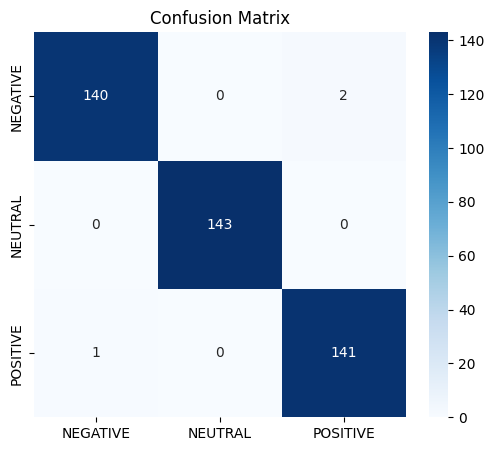

In [13]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")

plt.show()

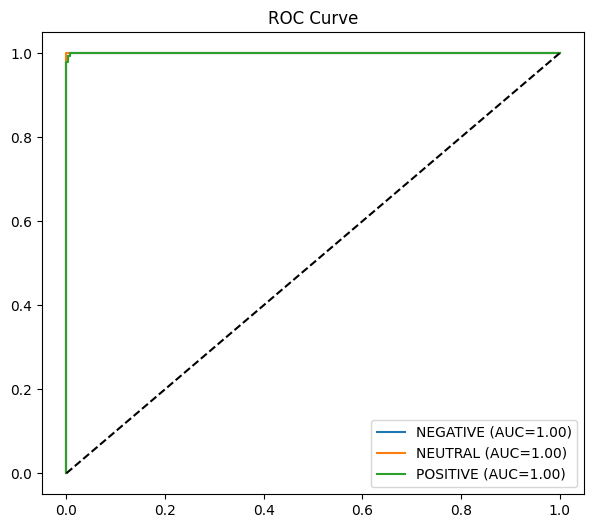

In [14]:
y_test_bin = label_binarize(y_test,classes=[0,1,2])

plt.figure(figsize=(7,6))

for i in range(3):

    fpr,tpr,_ = roc_curve(y_test_bin[:,i],y_pred_probs[:,i])

    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,label=f"{label_encoder.classes_[i]} (AUC={roc_auc:.2f})")


plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve")

plt.legend()

plt.show()

In [15]:
# ===============================
# Save Trained Models
# ===============================

import joblib


# Create directory
os.makedirs("saved_models", exist_ok=True)

deep_model.save("saved_models/deep_feature_model.h5")

print("Deep model saved")


feature_extractor.save("saved_models/feature_extractor_model.h5")

print("Feature extractor saved")


joblib.dump(xgb_model, "saved_models/xgboost_classifier.pkl")

print("XGBoost model saved")


joblib.dump(scaler, "saved_models/scaler.pkl")

print("Scaler saved")


joblib.dump(label_encoder, "saved_models/label_encoder.pkl")

print("Label encoder saved")


Deep model saved
Feature extractor saved
XGBoost model saved
Scaler saved
Label encoder saved
